In [1]:
import numpy as np
import matplotlib.pyplot as plt

import pandas as pd
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.linear_model import LinearRegression


In [2]:
df = pd.read_csv('SampleSuperstore.csv',encoding='latin',parse_dates=True)

In [3]:
df.shape

(9994, 21)

In [4]:
# After examining I decided that the row id is just the serial no so removing it before hand
df = df.drop(columns=['Row ID'])

In [5]:
# Also making the col names lowercase for better interpretability
df.columns = [x.lower().replace(' ','_') for x in df.columns]

In [6]:
df.head()

,order_id,order_date,ship_date,ship_mode,customer_id,customer_name,segment,country,city,state,postal_code,region,product_id,category,sub-category,product_name,sales,quantity,discount,profit
0,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [7]:
df.tail()

,order_id,order_date,ship_date,ship_mode,customer_id,customer_name,segment,country,city,state,postal_code,region,product_id,category,sub-category,product_name,sales,quantity,discount,profit
9989,CA-2014-110422,1/21/2014,1/23/2014,Second Class,TB-21400,Tom Boeckenhauer,Consumer,United States,Miami,Florida,33180,South,FUR-FU-10001889,Furniture,Furnishings,Ultra Door Pull Handle,25.248,3,0.2,4.1028
9990,CA-2017-121258,2/26/2017,3/3/2017,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,California,92627,West,FUR-FU-10000747,Furniture,Furnishings,Tenex B1-RE Series Chair Mats for Low Pile Car...,91.960,2,0.0,15.6332
9991,CA-2017-121258,2/26/2017,3/3/2017,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,California,92627,West,TEC-PH-10003645,Technology,Phones,Aastra 57i VoIP phone,258.576,2,0.2,19.3932
9992,CA-2017-121258,2/26/2017,3/3/2017,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,California,92627,West,OFF-PA-10004041,Office Supplies,Paper,"It's Hot Message Books with Stickers, 2 3/4"" x 5""",29.600,4,0.0,13.3200
9993,CA-2017-119914,5/4/2017,5/9/2017,Second Class,CC-12220,Chris Cortes,Consumer,United States,Westminster,California,92683,West,OFF-AP-10002684,Office Supplies,Appliances,"Acco 7-Outlet Masterpiece Power Center, Wihtou...",243.160,2,0.0,72.9480


In [8]:
# There are a lot of features here and we may need a lot feature extraction and feature transformation

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 20 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   order_id       9994 non-null   object 
 1   order_date     9994 non-null   object 
 2   ship_date      9994 non-null   object 
 3   ship_mode      9994 non-null   object 
 4   customer_id    9994 non-null   object 
 5   customer_name  9994 non-null   object 
 6   segment        9994 non-null   object 
 7   country        9994 non-null   object 
 8   city           9994 non-null   object 
 9   state          9994 non-null   object 
 10  postal_code    9994 non-null   int64  
 11  region         9994 non-null   object 
 12  product_id     9994 non-null   object 
 13  category       9994 non-null   object 
 14  sub-category   9994 non-null   object 
 15  product_name   9994 non-null   object 
 16  sales          9994 non-null   float64
 17  quantity       9994 non-null   int64  
 18  discount

In [10]:
# Looks fine for now but who knows what this dataset is hiding also almost every column is object even the dates

In [11]:
# For now I have these in mind :

'''  
Make a new feature duration which will be basically be the  subtraction of  ship_date and order_date

'''

'  \nMake a new feature duration which will be basically be the  subtraction of  ship_date and order_date\n\n'

In [12]:
top_10 = df['customer_name'].value_counts().head(10)

top_10_names = top_10.index.tolist()    # The customer names
top_10_counts = top_10.values           # Their frequency counts

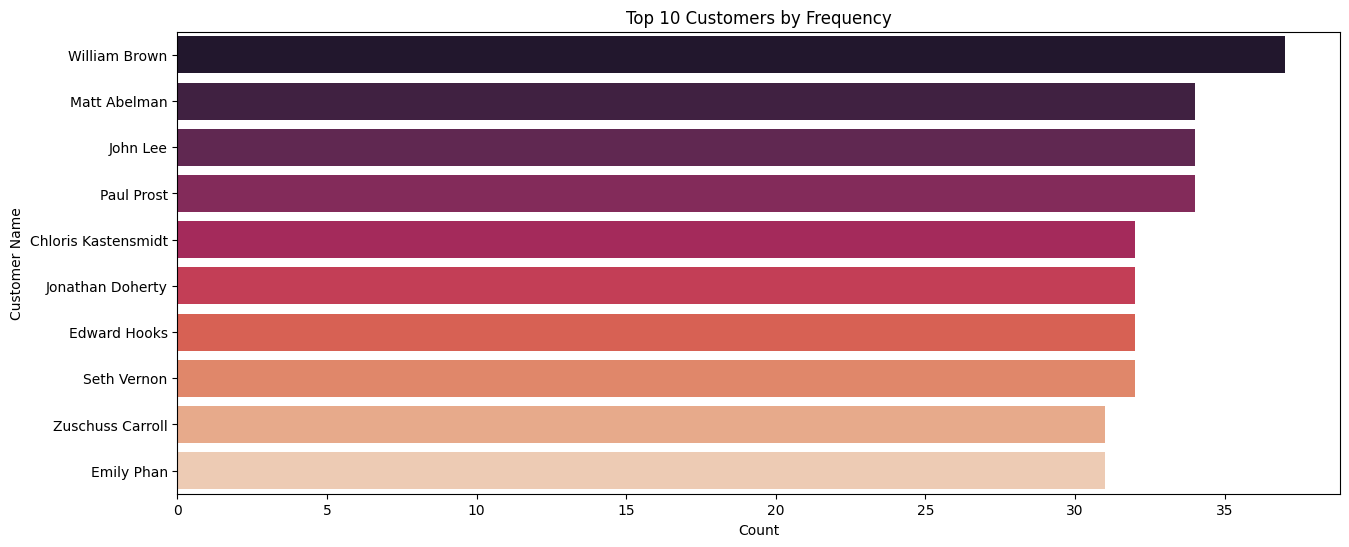

In [13]:
# Also let us check the customers who order the most

plt.figure(figsize=(15,6))
sns.barplot(x=top_10_counts, y=top_10_names,hue=top_10_names,palette='rocket')

plt.title('Top 10 Customers by Frequency')
plt.xlabel('Count')
plt.ylabel('Customer Name')
plt.show()

In [14]:
df['country'].nunique() # Basically all of the the consumers are from USA so this column will absolutely give any info to model
# So we will drop this

1

In [15]:
df = df.drop(columns=['country'])

In [16]:
# Let's also peak at the no_of_unique_values for other cols
df.nunique()

order_id         5009
order_date       1237
ship_date        1334
ship_mode           4
customer_id       793
customer_name     793
segment             3
city              531
state              49
postal_code       631
region              4
product_id       1862
category            3
sub-category       17
product_name     1850
sales            5825
quantity           14
discount           12
profit           7287
dtype: int64

In [17]:
# Also I think we can drop the customer_id or customer_name as both give the same info
# Who knows maybe both?

In [18]:
df.head()

,order_id,order_date,ship_date,ship_mode,customer_id,customer_name,segment,city,state,postal_code,region,product_id,category,sub-category,product_name,sales,quantity,discount,profit
0,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,Henderson,Kentucky,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,Henderson,Kentucky,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,Los Angeles,California,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,Fort Lauderdale,Florida,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,Fort Lauderdale,Florida,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [19]:
# For now let's convert the dates to a datetime object

In [20]:
df['order_date'] = pd.to_datetime(df['order_date'],errors='raise')
df['ship_date'] = pd.to_datetime(df['ship_date'],errors='raise')

In [21]:
df[['ship_date','order_date']].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   ship_date   9994 non-null   datetime64[ns]
 1   order_date  9994 non-null   datetime64[ns]
dtypes: datetime64[ns](2)
memory usage: 156.3 KB


In [22]:
# Also creating the new duration column
df['delivery_duration'] = df['ship_date'] - df['order_date']

In [23]:
df.head()['delivery_duration']

0   3 days
1   3 days
2   4 days
3   7 days
4   7 days
Name: delivery_duration, dtype: timedelta64[ns]

In [24]:
# Also I am removing the order_id as I think it won't contribute to the model much
df = df.drop(columns=['order_id'])

In [25]:
# The problem right now is I tried dropping the datetime cols for the randomforest regressor and then onverted all the object cols to numeric using the 
# ordinal encoeder before hand
#           RESULT : UNDERFITTING , -VE R2_SCORE

# Also beforehand I tried like dropping all the categorical cols with a lot of classes and then tried building the model on only 4 or 5 of numerical features 
# at the end of the dataset 
#           RESULT : UNDERFITTING , -VE R2_SCORE and huge MSE and RMSE

In [27]:
# As expected I got to know that this dataset was a Descriptive dataset and exists only for the purpose of analysis , not model building
# If we were to build a model from it we would need more features that actually correlate well with profit
# A strategy devised was to using a threshold create two classes for profit_column and then create a model
# but we wont be doing this as this dataset was not originally intentended too 

In [41]:
df.head(1)

,order_date,ship_date,ship_mode,customer_id,customer_name,segment,city,state,postal_code,region,product_id,category,sub-category,product_name,sales,quantity,discount,profit,delivery_duration
0,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,Henderson,Kentucky,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.96,2,0.0,41.9136,3 days


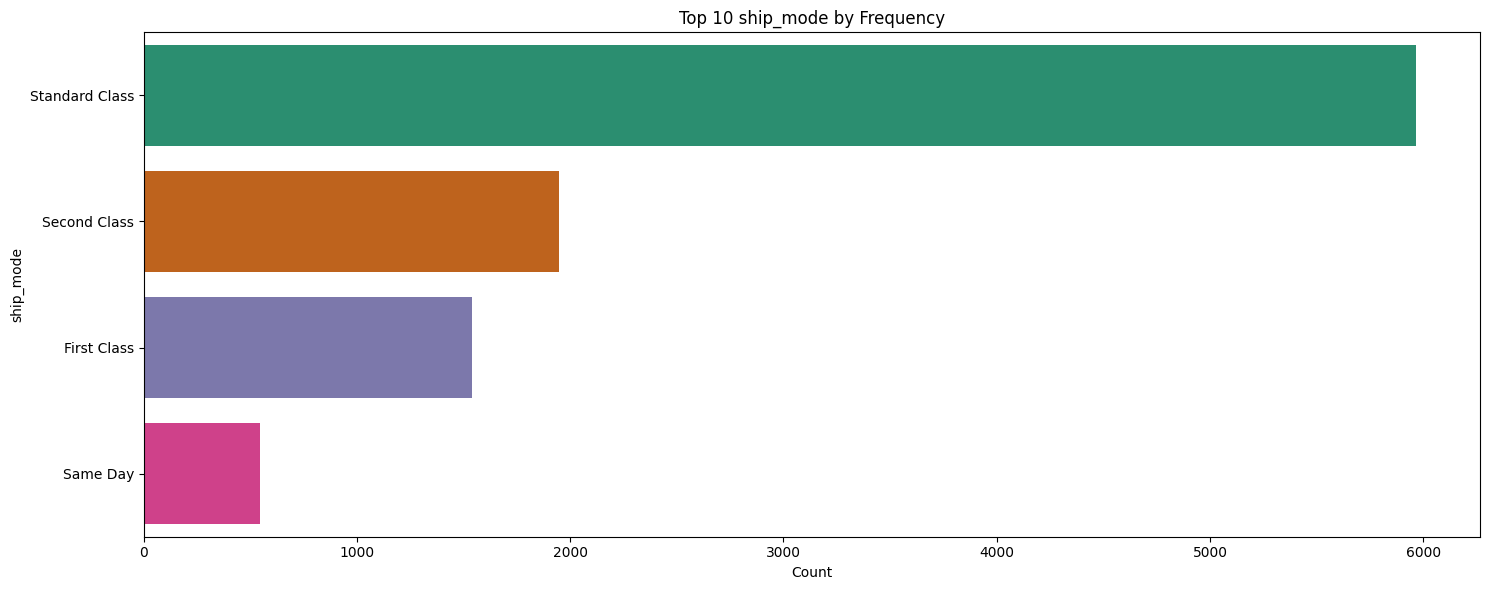

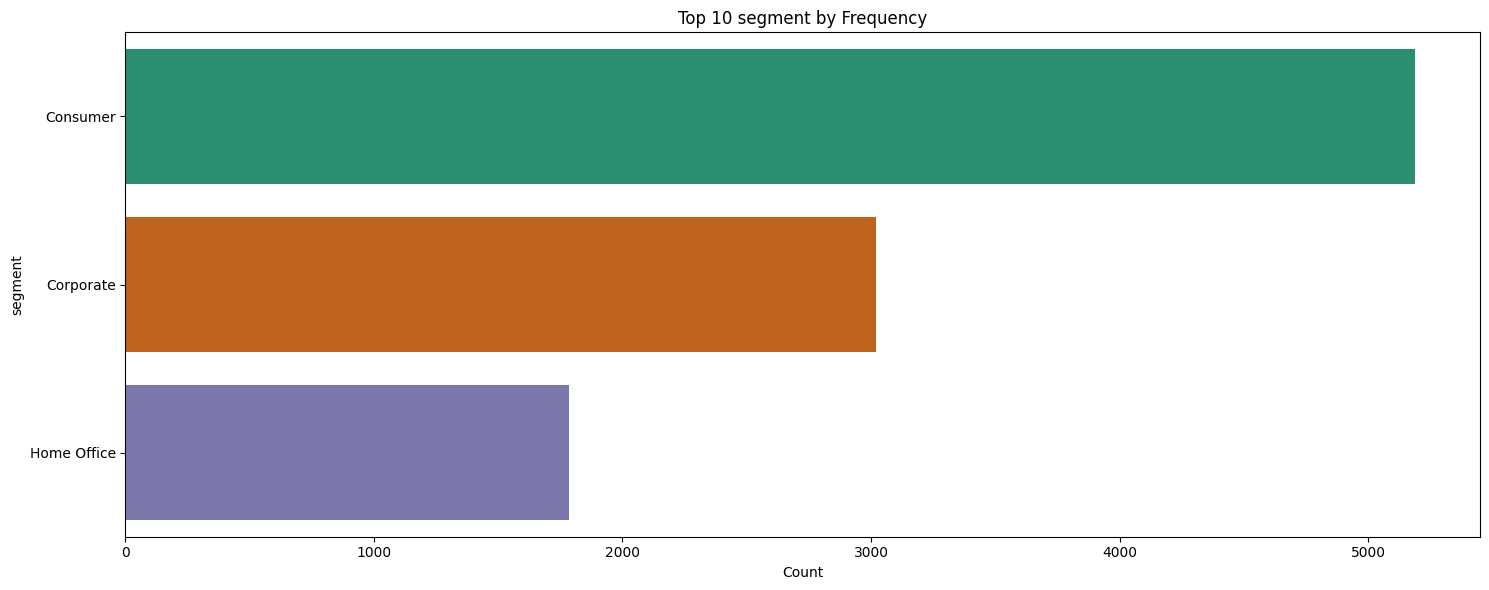

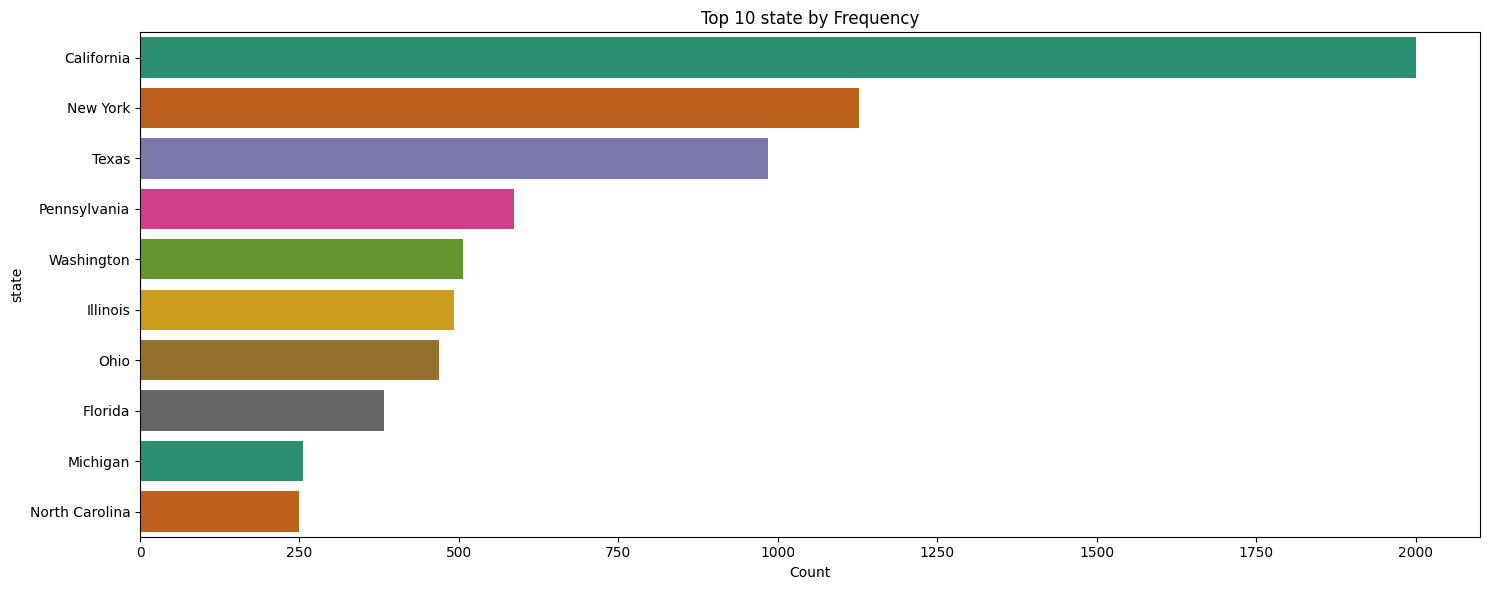

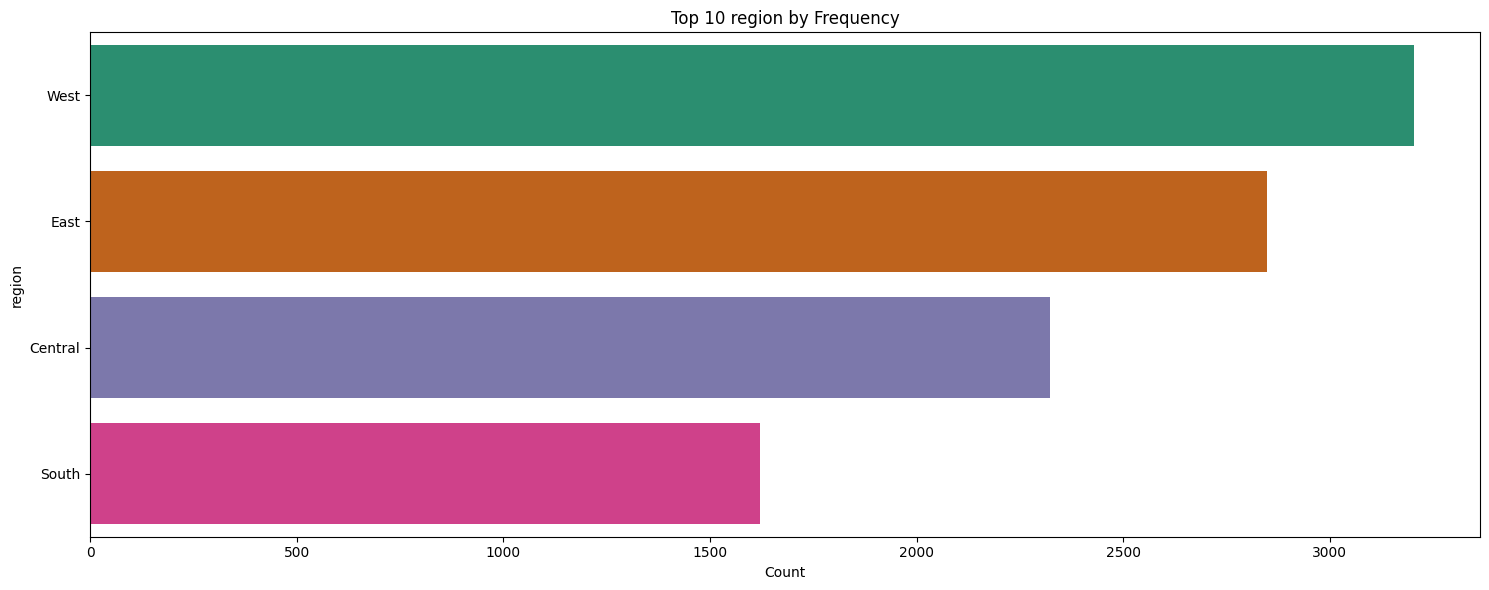

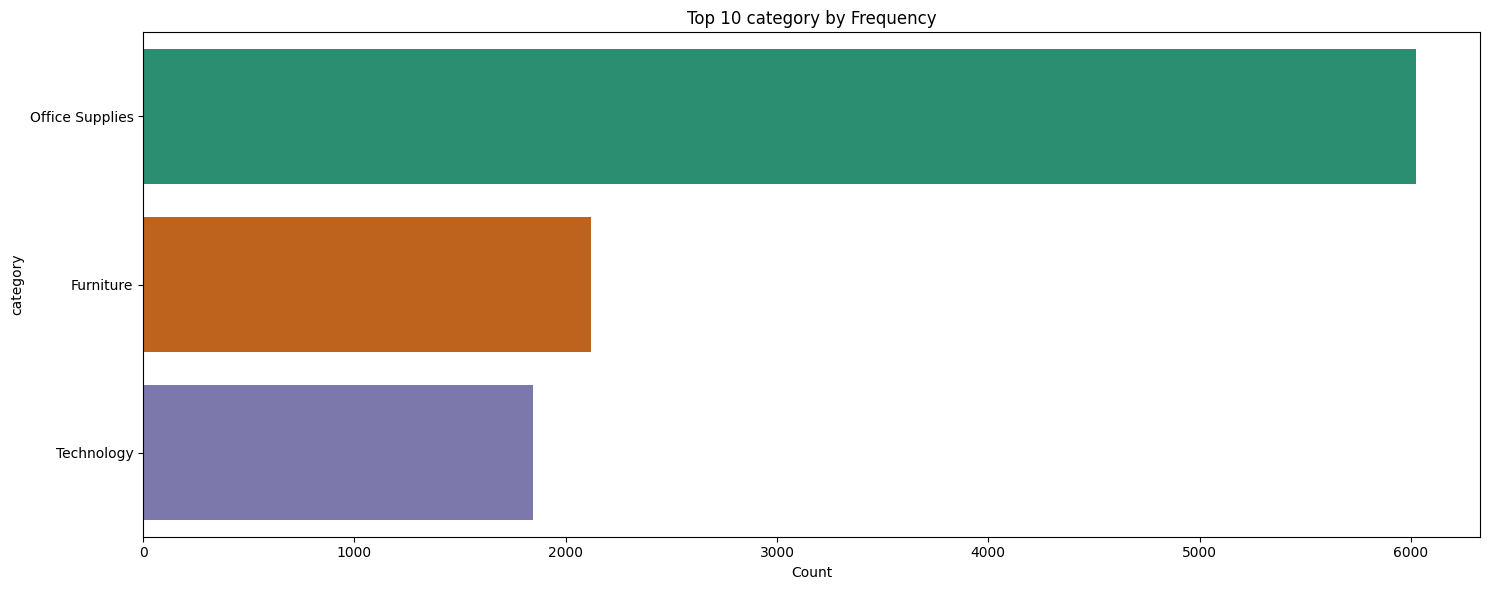

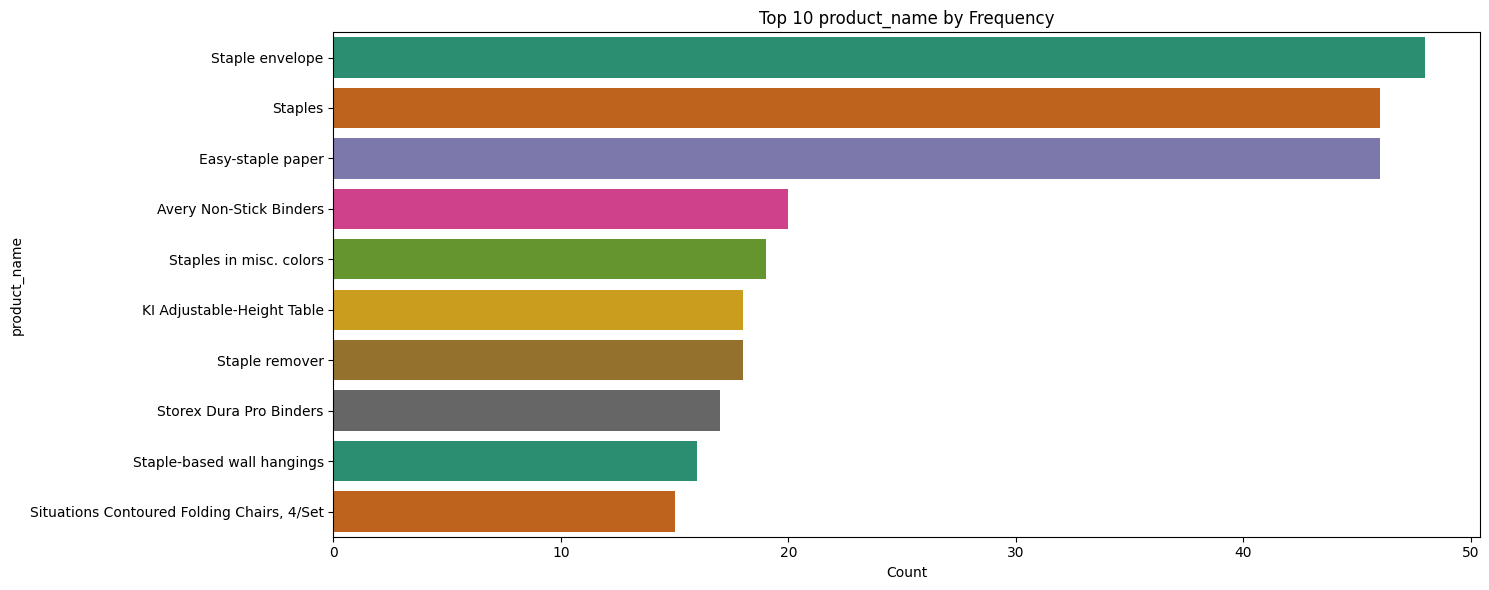

In [42]:
# We can other trends from this graph like below

for x in ['ship_mode','segment','state','region','category','product_name']:

    top_10_ = df[x].value_counts().head(10)

    plt.figure(figsize=(15,6))
    sns.barplot(y=top_10_.index, x=top_10_.values,hue=top_10_.index,palette='Dark2')

    plt.title(f'Top 10 {x} by Frequency')
    plt.xlabel('Count')
    plt.ylabel(x)

    plt.tight_layout()
    plt.show()